<a href="https://colab.research.google.com/github/sup-crypto/Machine-Learning/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings


In [2]:
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd


In [4]:
import numpy as np


In [5]:
from sklearn.datasets import load_iris


In [6]:
from sklearn.preprocessing import StandardScaler


In [7]:
raw_iris = load_iris()


In [8]:
features = raw_iris.feature_names


In [9]:
X_raw = raw_iris.data


In [10]:
y_true = raw_iris.target


In [11]:
scaler = StandardScaler()


In [12]:
X_scaled = scaler.fit_transform(X_raw)


In [13]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)


In [14]:
iris_df['species_id'] = y_true


In [15]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}


In [16]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [17]:
print("Standardized dataset dimensions:", X_scaled.shape)


Standardized dataset dimensions: (150, 4)


In [18]:
print("\nFirst 3 rows of standardized dataset:")



First 3 rows of standardized dataset:


In [19]:
print(iris_df.head(3))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [20]:
cov_matrix = np.cov(X_scaled.T)


In [21]:
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [22]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [23]:
print("\nEigenvalues (Variance components):\n", eigenvalues)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [24]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [25]:
from sklearn.decomposition import PCA


In [26]:
pca_model = PCA(n_components=2, random_state=42)


In [27]:
X_pca = pca_model.fit_transform(X_scaled)


In [28]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])


In [29]:
pca_df['species_name'] = iris_df['species_name']


In [30]:
print("Transformed PCA space dimensions:", X_pca.shape)


Transformed PCA space dimensions: (150, 2)


In [31]:
print("\nFirst 3 projected coordinates:")



First 3 projected coordinates:


In [32]:
print(pca_df.head(3))


       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [33]:
import matplotlib.pyplot as plt


In [34]:
import seaborn as sns


In [35]:
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='PC_1', ylabel='PC2'>

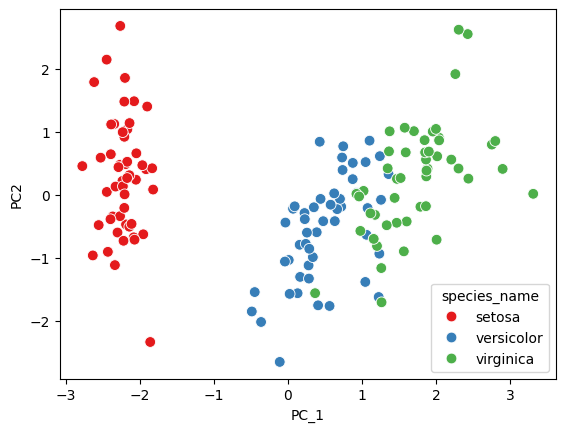

In [36]:
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)


Text(0.5, 1.0, '2-Component PCA Projection of Iris Dataset')

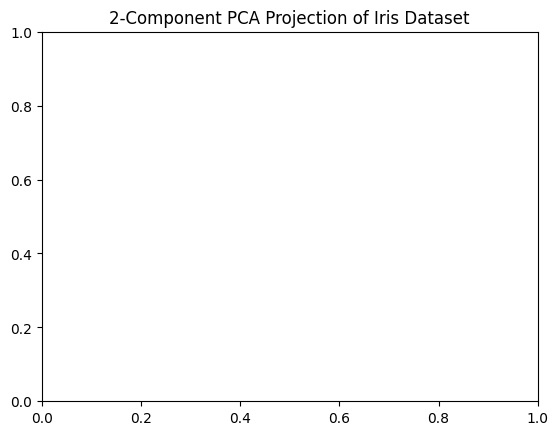

In [37]:
plt.title("2-Component PCA Projection of Iris Dataset")


Text(0.5, 0, 'Principal Component 1 (PC1)')

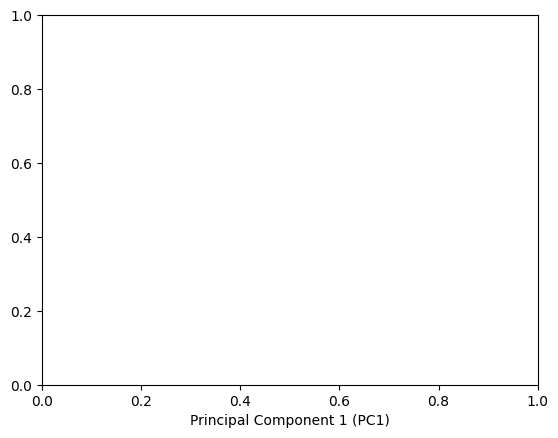

In [38]:
plt.xlabel("Principal Component 1 (PC1)")


Text(0, 0.5, 'Principal Component 2 (PC2)')

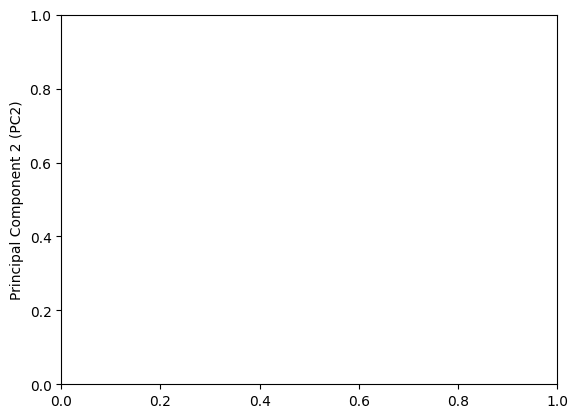

In [39]:
plt.ylabel("Principal Component 2 (PC2)")


In [40]:
plt.show()


In [41]:
explained_variance = pca_model.explained_variance_ratio_


In [42]:
cumulative_variance = np.sum(explained_variance)


In [43]:
print("Explained Variance per Component:")


Explained Variance per Component:


In [44]:
for i, var in enumerate(explained_variance):


SyntaxError: incomplete input (3377704477.py, line 1)

In [46]:
 for i, var in enumerate(explained_variance):
  print(f"  PC{i+1}: {var*100:.2f}%")

print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


  PC1: 72.96%
  PC2: 22.85%

Total Cumulative Variance Retained by 2 Components: 95.81%


In [47]:
import numpy as np


In [48]:
import pandas as pd


In [49]:
import matplotlib.pyplot as plt


In [50]:
from sklearn.datasets import load_iris


In [51]:
from sklearn.model_selection import train_test_split


In [52]:
from sklearn.preprocessing import StandardScaler


In [53]:
from sklearn.decomposition import PCA


In [54]:
from sklearn.linear_model import LogisticRegression


In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [56]:
iris = load_iris()


In [57]:
X = iris.data

In [58]:
y = iris.target

In [59]:
feature_names = iris.feature_names


In [60]:
target_names = iris.target_names


In [61]:
print("Dataset Shape:", X.shape)


Dataset Shape: (150, 4)


In [62]:
print("Features:", feature_names)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [63]:
print("Classes:", target_names)


Classes: ['setosa' 'versicolor' 'virginica']


In [64]:
_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# Step 4: Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# PART A: CLASSIFICATION WITHOUT PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")

# Create Logistic Regression model
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
model_without_pca.fit(
    X_train_scaled,
    y_train
)

# Predict test data
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

# Calculate accuracy
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")

# Apply PCA
pca = PCA(
    n_components=2
)

# Fit PCA only on training data
X_train_pca = pca.fit_transform(
    X_train_scaled
)

# Transform test data using the same PCA
X_test_pca = pca.transform(
    X_test_scaled
)

# Display explained variance
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


# Create Logistic Regression model
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model using PCA features
model_with_pca.fit(
    X_train_pca,
    y_train
)

# Predict test data
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

# Calculate accuracy
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

print("Accuracy with PCA:",
      accuracy_with_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)


# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

print("\n========================================")
print("COMPARISON")
print("========================================")

comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

print(comparison)


# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA")
plt.grid()

plt.show()

NameError: name 'X_train' is not defined

In [65]:
import warnings


In [66]:
warnings.filterwarnings("ignore")


In [67]:
from sklearn.cluster import KMeans


In [68]:
import matplotlib.pyplot as plt


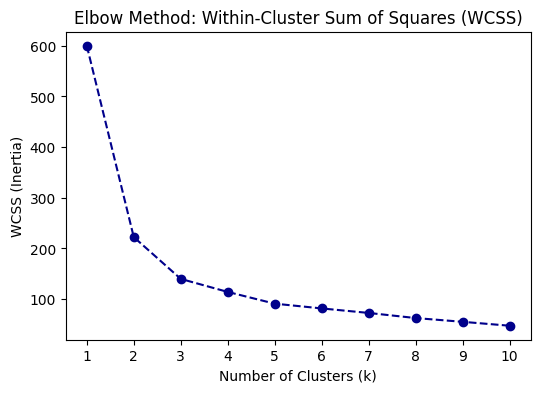

In [69]:
wcss = []
k_range = range(1, 11)

# Fit K-Means iteratively
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


In [70]:
from sklearn.metrics import silhouette_score


In [71]:
silhouette_scores = []
k_eval = range(2, 6)

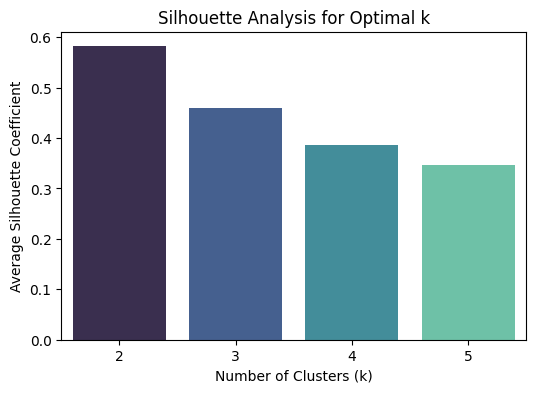

k = 2 yielded the highest silhouette coefficient (0.5818).


In [72]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

# Plot Silhouette scores
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()

# Find and print the best k
best_k = k_eval[np.argmax(silhouette_scores)]
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")


In [73]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)


In [74]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)


In [75]:
iris_df['cluster_raw'] = kmeans_raw_labels


In [76]:
print("K-Means clustering complete. First 5 sample allocations:")


K-Means clustering complete. First 5 sample allocations:


In [77]:
print(iris_df[['species_name', 'cluster_raw']].head(5))


  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [78]:
raw_centroids_scaled = kmeans_raw.cluster_centers_


In [79]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)


NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [80]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)


NameError: name 'raw_centroids_physical' is not defined

In [83]:

# Extract raw centroid coordinates in standardized space
raw_centroids_scaled = kmeans_raw.cluster_centers_

raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

# Store in a summary table
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")
print(centroids_df)


NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [84]:
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [85]:
raw_data = scaler.inverse_transform(X_scaled)


NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [86]:
plt.figure(figsize=(6, 4))

# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)

# Plot the continuous data points colored by cluster assignment
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2],
    raw_centroids_physical[:, 3],
    color='red',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

<Figure size 600x400 with 0 Axes>

In [87]:
import warnings
/

()

In [88]:
warnings.filterwarnings("ignore")


In [89]:
from sklearn.cluster import KMeans


In [90]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)


In [91]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)



In [92]:
iris_df['cluster_pca'] = kmeans_pca_labels


In [93]:
print("PCA space K-Means clustering completed successfully.")


PCA space K-Means clustering completed successfully.


In [94]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score


In [95]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)


In [96]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)


In [97]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)


In [98]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)


In [99]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")


--- Internal Validation (Unsupervised Quality Metrics) ---


In [100]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")


Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [101]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


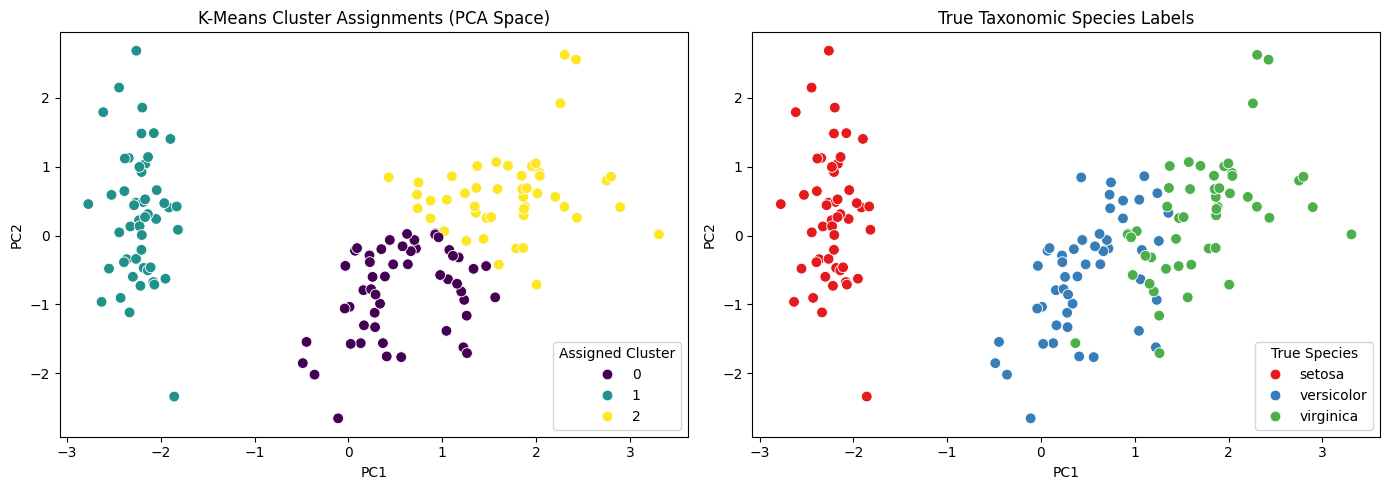

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels,
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name',
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()


In [105]:
comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)


NameError: name 'ari_raw' is not defined

In [106]:
print("--- Clustering Performance Summary: Raw vs. PCA ---")
print(comparison_metrics.round(4))


--- Clustering Performance Summary: Raw vs. PCA ---


NameError: name 'comparison_metrics' is not defined